# 2.2 From Distance to Norm

In [10]:
import numpy as np
p = np.array([1, 2])
q = np.array([4, 5])
v = q - p

In [12]:
print(f"Vector p: {p}")
print(f"Vector q: {q}")
print(f"Difference Vector : {v}")

Vector p: [1 2]
Vector q: [4 5]
Difference Vector : [3 3]


# 2.3 L₂ Norm

In [15]:
l2 = np.linalg.norm(v)  
print(f"L2 distance: {l2}")

L2 distance: 4.242640687119285


# 2.4 L₁ Norm

In [18]:
l1 = np.linalg.norm(v, ord=1)
print(f"L1 distance: {l1}")

L1 distance: 6.0


# 2.5 L∞ Norm

In [21]:
linf = np.linalg.norm(v, ord=np.inf)
print(f"L∞ distance: {linf}")

L∞ distance: 3.0


# 2.8 Identity Matrix

In [17]:
import numpy as np

I = np.eye(3)
x = np.array([5, -2, 1])
xt = I @ x

print(f"Identity Matrix:\n{I}")
print(f"Before Transformation with I:\n{x}")
print(f"After Transformation with I:\n{xt}")


Identity Matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Before Transformation with I:
[ 5 -2  1]
After Transformation with I:
[ 5. -2.  1.]


# 2.9 Transpose Aᵀ

In [26]:
import numpy as np

A = np.array([[1,3,5],
              [2,4,6]])
At = A.T

print(f"A, before Transpose operation A:\n{A}")
print(f"Aᵀ, after Transpose operation of A, Aᵀ:\n{At}")

A, before Transpose operation A:
[[1 3 5]
 [2 4 6]]
Aᵀ, after Transpose operation of A, Aᵀ:
[[1 2]
 [3 4]
 [5 6]]


# 2.10 Inverse A⁻¹

In [36]:
A = np.array([[2, 1],
              [1, 4]])

A_inv = np.linalg.inv(A)
A_x_A_inv = A @ A_inv

print(f"A:\n{A}")
print(f"Inverse of A, A⁻¹:\n{A_inv}")
print(f"A multiplied by its inverse A⁻¹:\n{A_x_A_inv}")


A:
[[2 1]
 [1 4]]
Inverse of A, A⁻¹:
[[ 0.57142857 -0.14285714]
 [-0.14285714  0.28571429]]
A multiplied by its inverse A⁻¹:
[[1. 0.]
 [0. 1.]]


# 2.11 Determinant (det(A))

In [79]:
A1 = np.array([
    [0, -1],
    [1,  0]
])
det_A1 = np.linalg.det(A1) # Rotation: preserves area → det = 1.
print(f"Determinant: {det_A1}\nExplanation: Rotation | Preserves Area")

Determinant: 1.0
Explanation: Rotation | Preserves Area


In [75]:
A2 = np.array([
    [2, 0],
    [0, 1]
])
det_A2 = np.linalg.det(A2) # Stretch: Unit square becomes area-2 rectangle.
print(f"Determinant: {det_A2}\nExplanation: Stretch | Unit square area becomes double and form a rectangle")

Determinant: 2.0
Explanation: Stretch | Unit square area becomes double and form a rectangle


In [81]:
A3 = np.array([
    [1, 2],
    [2, 4]
])
det_A3 = np.linalg.det(A3) # Singular: Rows are linearly dependent → collapses area → no inverse.
print(f"Determinant: {det_A3}\nExplanation: Singular | Rows are linearly dependent → collapses area → no inverse.")

Determinant: 0.0
Explanation: Singular | Rows are linearly dependent → collapses area → no inverse.


In [83]:
A4 = np.array([
    [-3, 0],
    [0, 1]
])
det_A4 = np.linalg.det(A4) # Flip + Stretch: Stretches by 3 + flips.
print(f"Determinant: {det_A4}\nExplanation: Flip + Stretch | Stretches by 3 + flips.")

Determinant: -3.0000000000000004
Explanation: Flip + Stretch | Stretches by 3 + flips.


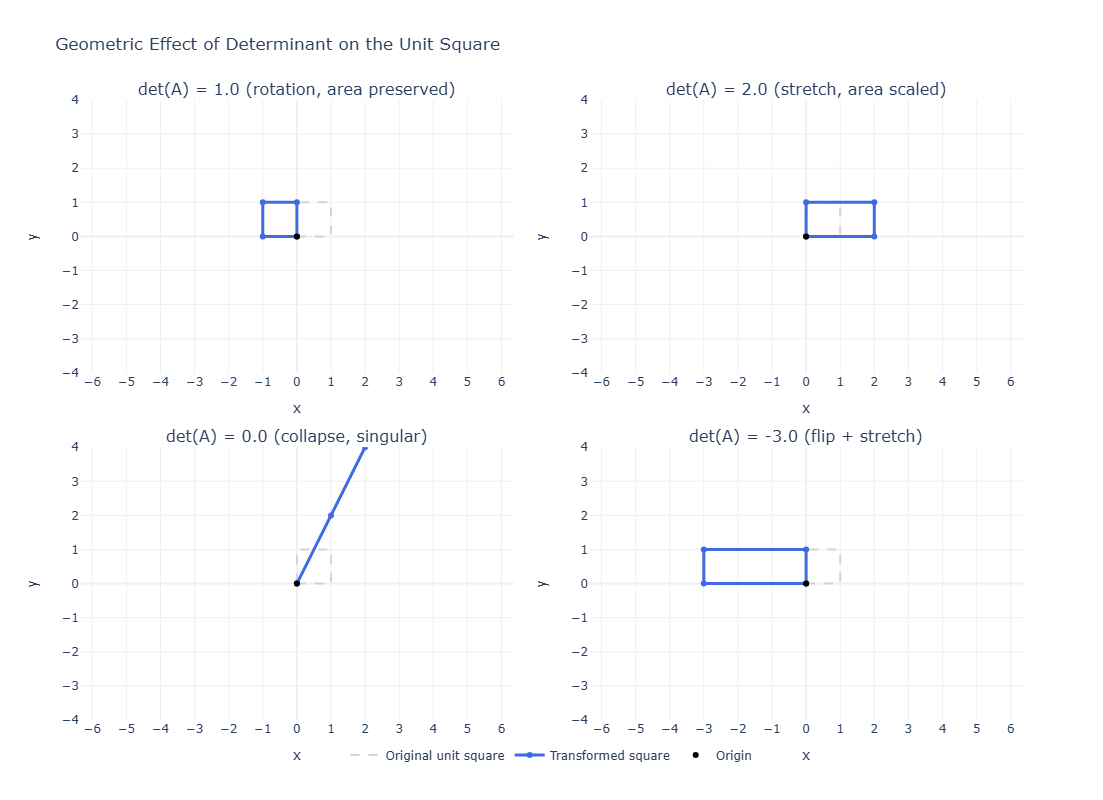

In [69]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Helper: build square and apply matrix ---
def transform_square(A):
    """
    A: 2x2 matrix
    Returns original square (2xN) and transformed square (2xN)
    """
    # unit square vertices, closed loop
    square = np.array([
        [0, 1, 1, 0, 0],   # x
        [0, 0, 1, 1, 0]    # y
    ])  # shape (2, 5)
    transformed = A @ square
    return square, transformed

# --- Define matrices with different determinants ---
A1 = np.array([[0, -1],
               [1,  0]])      # rotation 90°, det = 1

A2 = np.array([[2, 0],
               [0, 1]])       # stretch in x, det = 2

A3 = np.array([[1, 2],
               [2, 4]])       # rows dependent, det = 0 (collapse)

A4 = np.array([[-3, 0],
               [ 0, 1]])      # flip in x + stretch, det = -3

mats = [A1, A2, A3, A4]
titles = [
    f"det(A) = {np.linalg.det(A1):.1f} (rotation, area preserved)",
    f"det(A) = {np.linalg.det(A2):.1f} (stretch, area scaled)",
    f"det(A) = {np.linalg.det(A3):.1f} (collapse, singular)",
    f"det(A) = {np.linalg.det(A4):.1f} (flip + stretch)"
]

# --- Create subplots ---
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=titles,
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

# common axis limits so comparisons are clear
axis_range = [-4, 4]

for idx, (A, title) in enumerate(zip(mats, titles), start=1):
    row = 1 if idx <= 2 else 2
    col = 1 if idx in [1, 3] else 2
    
    sq, sq_T = transform_square(A)
    
    # Original unit square (light gray dashed)
    fig.add_trace(
        go.Scatter(
            x=sq[0, :], y=sq[1, :],
            mode="lines",
            line=dict(color="lightgray", width=2, dash="dash"),
            name="Original unit square",
            showlegend=True if idx == 1 else False  # show legend only once
        ),
        row=row, col=col
    )
    
    # Transformed shape (colored polygon)
    fig.add_trace(
        go.Scatter(
            x=sq_T[0, :], y=sq_T[1, :],
            mode="lines+markers",
            line=dict(color="royalblue", width=3),
            marker=dict(size=6),
            name="Transformed square",
            showlegend=True if idx == 1 else False
        ),
        row=row, col=col
    )
    
    # Optional: show origin as reference
    fig.add_trace(
        go.Scatter(
            x=[0], y=[0],
            mode="markers",
            marker=dict(size=6, color="black"),
            name="Origin",
            showlegend=True if idx == 1 else False
        ),
        row=row, col=col
    )
    
    # Axes styling for this subplot
    fig.update_xaxes(
        range=axis_range,
        zeroline=True,
        showgrid=True,
        dtick=1,
        title_text="x",
        row=row, col=col
    )
    fig.update_yaxes(
        range=axis_range,
        zeroline=True,
        showgrid=True,
        dtick=1,
        title_text="y",
        scaleanchor=f"x{idx}",  # lock aspect ratio per subplot
        scaleratio=1,
        row=row, col=col
    )

fig.update_layout(
    title="Geometric Effect of Determinant on the Unit Square",
    template="plotly_white",
    width=950,
    height=800,
    legend=dict(
        bgcolor="rgba(255,255,255,0.8)",
        orientation="h",
        yanchor="bottom",
        y=-0.08,
        xanchor="center",
        x=0.5
    )
)

fig.show()


---